In [1]:
from pathlib import Path
import yaml
import subprocess
import numpy as np
import pandas as pd
from formulaic import model_matrix
from matplotlib import pyplot as plt
from time import perf_counter
import seaborn as sns
sns.set_theme()

def show_matrix(m: pd.DataFrame, cmap="coolwarm", cbar=False, annot=True, **kwargs):
    axim = sns.heatmap(m.rename(columns=dict(Intercep="I")), cmap=cmap, cbar=cbar, annot=annot, **kwargs)
    axim.xaxis.set_ticks_position("top")
    axim.yaxis.set_ticks_position("right")

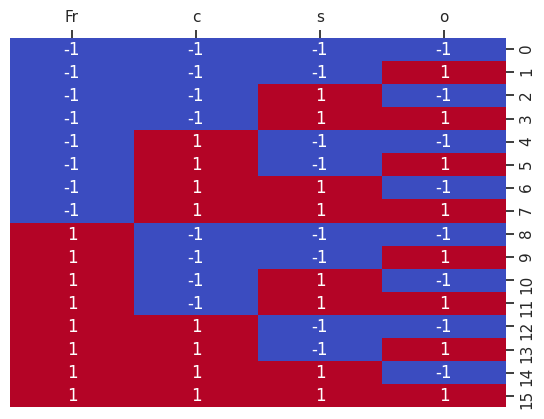

In [2]:
def factorial_2(N: int, S: int=2):
    rows = np.arange(S**N)
    periods = S**np.arange(0, N)[::-1]
    E = 2*(rows[:, None] % periods == 0) - 1
    return np.cumprod(-E, axis=0)

columns = "Fr c s o".split()
E = factorial_2(len(columns))
E = pd.DataFrame(E, columns=columns)

show_matrix(E)
plt.show()

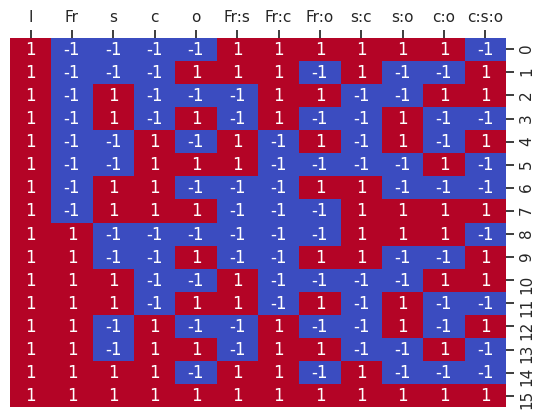

In [3]:
M = model_matrix("Fr+s+c+o + Fr:s + Fr:c + Fr:o + s:c + s:o + c:o + c:s:o", E).rename(columns=dict(Intercept="I"))
show_matrix(M)
M.to_csv("matrix_model.csv", index=False)

In [4]:
# Pour les simulations
bounds = pd.DataFrame(dict(
    Fr=(2, 5),
    s=(0.5, 1.5),
    c=(0.9995, 1.0005),
    o=(1, 2)
))[E.columns]

columns = bounds.columns
bounds = bounds.to_numpy()
mid = bounds.mean(axis=0)
lower = bounds[0]
upper = bounds[1]

values = np.sqrt((upper/lower)**E*upper*lower)
# E_test = np.log(values**2/(lower*upper)) / np.log(upper/lower)
# values = (max_values-min_values) * (1+E)/2 + min_values
values = pd.DataFrame(values, columns=columns)
values.to_csv("matrix_experiment.csv", index=False)
display(values)
# show_matrix(pd.DataFrame(E_test, columns=columns))

,Fr,c,s,o
0,2.0,0.9995,0.5,1.0
1,2.0,0.9995,0.5,2.0
2,2.0,0.9995,1.5,1.0
3,2.0,0.9995,1.5,2.0
4,2.0,1.0005,0.5,1.0
5,2.0,1.0005,0.5,2.0
6,2.0,1.0005,1.5,1.0
7,2.0,1.0005,1.5,2.0
8,5.0,0.9995,0.5,1.0
9,5.0,0.9995,0.5,2.0


In [5]:
config = dict(
    xmin=-50,
    xmax=+1000,
    ymin=-500,
    ymax=+500,
    avalanche_depth=5,  # m
    avalanche_volume=2000,  # m³
    avalanche_width=20,  # m
    avalanche_speed=None,
    slope=None,
    curvature=None,
    openness=None,
)

outdir = Path("/media/giboul/Data/Giboulot/DoE")# /_output{i:0>4}"

spinning_slash = ["|", "/", "-", "\\"]

for experiment in range(E.shape[0]):
    
    config.update(
        avalanche_speed=float(values["Fr"].iloc[experiment]*np.sqrt(9.81*config["avalanche_depth"])),
        slope=float(values["s"].iloc[experiment]),
        curvature=float(values["c"].iloc[experiment]-1),
        openness=float(values["o"].iloc[experiment]-1),
    )
    with open("config.yaml", "w") as file:
        yaml.safe_dump(config, file)
    path = outdir / f"_output{experiment:0>4}"
    print(f"{str(path)}: ", end="", flush=True)
    # Path(path).mkdir(exist_ok=True)
    with open(path / "out.log", "w") as std_file:
        with open(path / "err.log", "w") as err_file:
            proc = subprocess.Popen(
                f"make simulation OUTDIR={path} OMP_NUM_PROCS=10".split(),
                stdout=std_file,
                stderr=err_file,
            )
            if True:
                t0 = perf_counter()
                j = 0
                while proc.poll() is None:
                    t1 = perf_counter()
                    if t1-t0 > 0.5:
                        current_step = list(sorted(path.glob("fort.q????")))
                        current_step = int(current_step[-1].name[6:]) if current_step else 0
                        print(f"\r{str(path)}: {spinning_slash[j]} {current_step:>4}", end="", flush=True)
                        j = (j+1) % len(spinning_slash)
                        t0 = t1
    print(flush=True)

/media/giboul/Data/Giboulot/DoE/_output0000: \   11

KeyboardInterrupt: 

In [ ]:
from pathlib import Path
import numpy as np
from clawpack.geoclaw import fgmax_tools

files = Path("/media/giboul/Data/Giboulot/DoE/").glob("_output*")
E = np.loadtxt("matrix_experiment.csv", delimiter=",", skiprows=1)
hmax = np.zeros(E.shape[0], dtype=np.float64)
for i, outdir in enumerate(sorted(files)):
    try:
        fg = fgmax_tools.FGmaxGrid()
        fg.read_fgmax_grids_data(2, outdir / "fgmax_grids.data")
        fg.read_output(outdir=outdir)
        mask = fg.B<=0
        hmax[i] = (fg.B+fg.h)[mask].max()
        imax = (fg.B+fg.h)[mask].argmax()
        print(f"{i = }: {fg.X[mask][imax]:.1f} {fg.Y[mask][imax]:.1f} => {hmax[i]:.2f} m ", flush=True)
    except ValueError as e:
        print(e)
print(hmax)
np.savetxt("hmax.txt", hmax[:, None])

Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0000/fgmax0002.txt ...
i = 0: 11.0 0.0 => 6.57 m 
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0001/fgmax0002.txt ...
i = 1: 9.0 0.0 => 10.54 m 
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0002/fgmax0002.txt ...
i = 2: 8.0 0.0 => 8.61 m 
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0003/fgmax0002.txt ...
i = 3: 13.0 0.0 => 14.75 m 
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0004/fgmax0002.txt ...
i = 4: 11.0 0.0 => 6.63 m 
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0005/fgmax0002.txt ...
i = 5: 19.0 0.0 => 10.92 m 
Reading input for fgno=2, point_style = 2 
Reading /media/giboul/Data/Giboulot/DoE/_output0006/fgmax0002.txt ...
i = 6: 8.0 0.0 => 8.73 m 
Reading input for fg

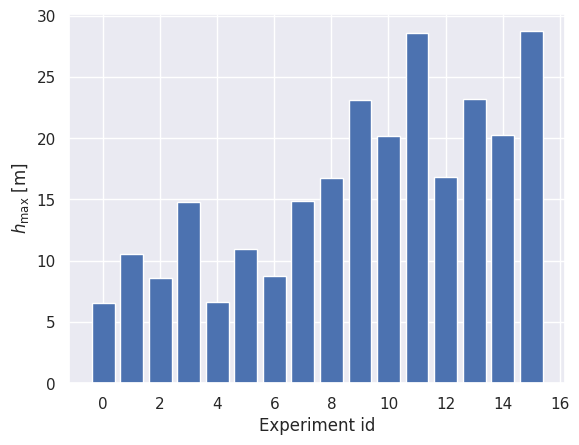

In [ ]:
from matplotlib import pyplot as plt
plt.bar(np.arange(hmax.size), hmax)
plt.xlabel("Experiment id")
plt.ylabel(r"$h_\mathrm{max}$ [m]")
plt.show()